In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

C:\Users\thesp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
#LOAD DATA
df = pd.read_csv("amazon_sales_dataset.csv")
df.head()

,Order_id,Order_Date,Product,Category,Sub_Category,Segment,Price,Quantity,Purchase_Type,Payment_Method,Shipping_date,Delivery_date,Customer_id,Customer_gender,Customer_age,Customer_city,Region,Rating
0,1,2023-03-13,Fiction Product 13,Books,Fiction,Education,11.52,1,Online,PayPal,2023-03-16,2023-03-18,16050,Female,38,"Kansas City, Missouri",North,1
1,2,2020-02-15,Fitness Product 72,Sports,Fitness,Lifestyle,15.88,1,Online,Credit Card,2020-02-18,2020-02-18,44349,Female,40,"El Paso, Texas",South,3
2,3,2021-05-17,Kids Product 457,Clothing,Kids,Fashion,16.22,1,Online,PayPal,2021-05-20,2021-05-20,38699,Male,27,"Portland, Oregon",West,4
3,4,2021-02-11,TV Product 17,Electronics,TV,Technology,11.30,1,Store,Money,2021-02-12,2021-02-14,14329,Female,38,"Columbus, Ohio",North,2
4,5,2023-09-06,Men Product 259,Clothing,Men,Fashion,12.05,1,Online,Gift Card,2023-09-09,2023-09-09,36782,Male,33,"Tucson, Arizona",West,3


In [6]:
# Information about DataFrame
df.info()

# Statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_id         200000 non-null  int64  
 1   Order_Date       200000 non-null  object 
 2   Product          200000 non-null  object 
 3   Category         200000 non-null  object 
 4   Sub_Category     200000 non-null  object 
 5   Segment          200000 non-null  object 
 6   Price            200000 non-null  float64
 7   Quantity         200000 non-null  int64  
 8   Purchase_Type    200000 non-null  object 
 9   Payment_Method   200000 non-null  object 
 10  Shipping_date    200000 non-null  object 
 11  Delivery_date    200000 non-null  object 
 12  Customer_id      200000 non-null  int64  
 13  Customer_gender  200000 non-null  object 
 14  Customer_age     200000 non-null  int64  
 15  Customer_city    200000 non-null  object 
 16  Region           200000 non-null  obje

,Order_id,Price,Quantity,Customer_id,Customer_age,Rating
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,22.758739,1.944805,24974.658030,34.722475,3.751415
std,57735.171256,12.105892,1.351631,14425.541199,9.599315,1.136150
min,1.000000,2.470000,1.000000,1.000000,18.000000,1.000000
25%,50000.750000,14.310000,1.000000,12476.000000,28.000000,3.000000
50%,100000.500000,20.100000,1.000000,24941.000000,35.000000,4.000000
75%,150000.250000,28.180000,2.000000,37503.000000,41.000000,5.000000
max,200000.000000,202.020000,10.000000,50000.000000,78.000000,5.000000


In [7]:
# CLEAN DATA
# Remove rows with missing essential values
df = df.dropna(subset=["Order_Date", "Price", "Quantity"])

In [8]:
# Type casting
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Price"] = pd.to_numeric(df["Price"])
df["Quantity"] = pd.to_numeric(df["Quantity"])

In [9]:
# Create sales column
df["Sales"] = df["Price"] * df["Quantity"]

In [10]:
#MONTHLY TIME SERIES
ts = df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"].sum()
ts.index = ts.index.to_timestamp()

Text(0, 0.5, 'Frequency')

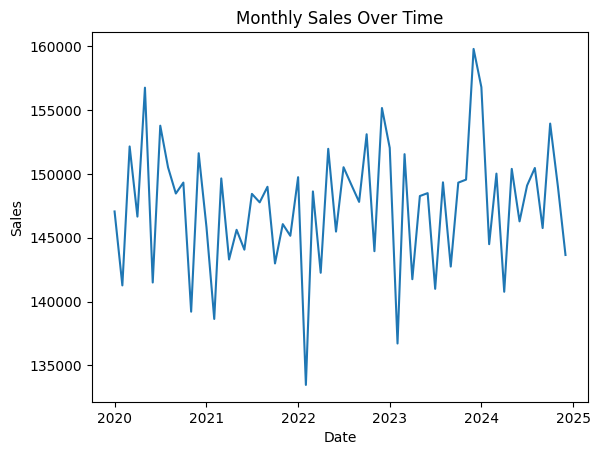

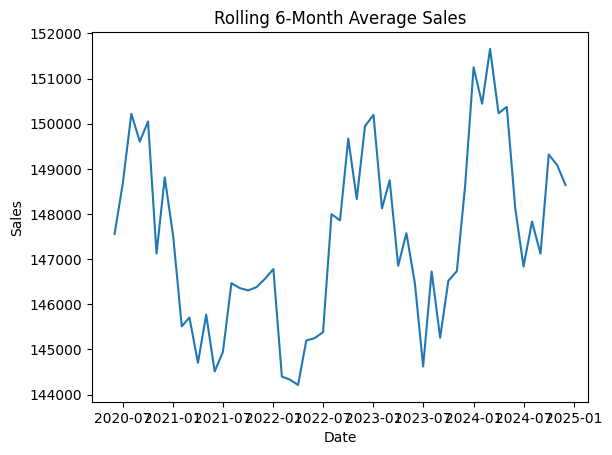

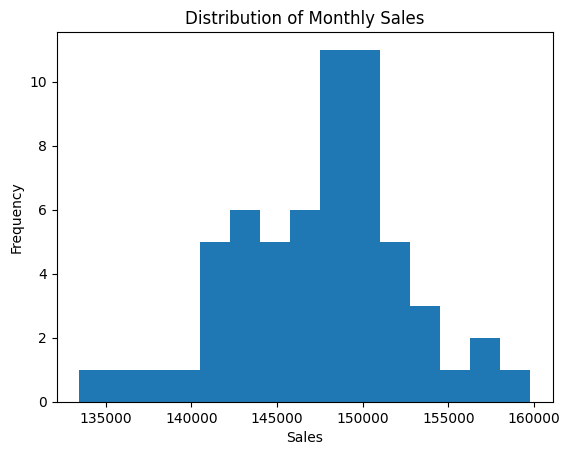

In [11]:
# EXPLORATORY DATA ANALYSIS
plt.figure()
plt.plot(ts)
plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.figure()
plt.plot(ts.rolling(6).mean())
plt.title("Rolling 6-Month Average Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.figure()
plt.hist(ts, bins=15)
plt.title("Distribution of Monthly Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

Text(0.5, 1.0, 'ARIMA Forecast')

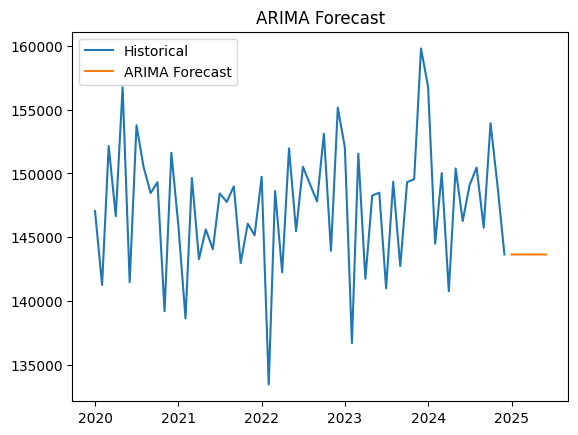

In [12]:
# ARIMA MODEL
model_arima = ARIMA(ts, order=(1,1,1))
fit_arima = model_arima.fit()
forecast_arima = fit_arima.forecast(6)

plt.figure()
plt.plot(ts, label="Historical")
plt.plot(forecast_arima, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA Forecast")

C:\Users\thesp\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


Text(0.5, 1.0, 'SARIMA Forecast')

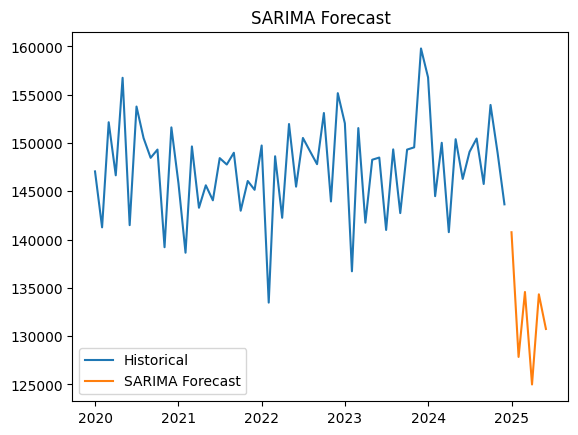

In [13]:
# SARIMA MODEL

model_sarima = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,12))
fit_sarima = model_sarima.fit()
forecast_sarima = fit_sarima.forecast(6)

plt.figure()
plt.plot(ts, label="Historical")
plt.plot(forecast_sarima, label="SARIMA Forecast")
plt.legend()
plt.title("SARIMA Forecast")

15:17:53 - cmdstanpy - INFO - Chain [1] start processing
15:17:54 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\thesp\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


Text(0.5, 1.0, 'Prophet Forecast')

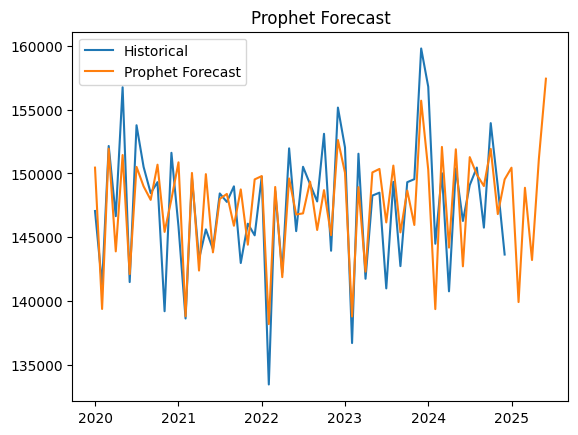

In [14]:
# PROPHET MODEL

prophet_df = ts.reset_index()
prophet_df.columns = ["ds", "y"]

model_prophet = Prophet()
model_prophet.fit(prophet_df)

future = model_prophet.make_future_dataframe(periods=6, freq="M")
forecast_prophet = model_prophet.predict(future)

plt.figure()
plt.plot(prophet_df["ds"], prophet_df["y"], label="Historical")
plt.plot(forecast_prophet["ds"], forecast_prophet["yhat"], label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast")

In [16]:
#Avaliação de Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Split train/test
train = ts.iloc[:-12]
test = ts.iloc[-12:]

In [17]:
# Train each model again using train only

# ARIMA
m_arima = ARIMA(train, order=(1,1,1)).fit()
pred_arima = m_arima.forecast(steps=12)

In [18]:
# SARIMA
m_sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
pred_sarima = m_sarima.forecast(steps=12)

C:\Users\thesp\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [19]:
# Prophet
prop_train = train.reset_index()
prop_train.columns = ["ds", "y"]

m_prophet = Prophet()
m_prophet.fit(prop_train)

future = m_prophet.make_future_dataframe(periods=12, freq="M")
forecast = m_prophet.predict(future)
pred_prophet = forecast.iloc[-12:]["yhat"]

15:19:05 - cmdstanpy - INFO - Chain [1] start processing
15:19:06 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\thesp\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [20]:
#Calcular Erro dos Modelos
def eval_model(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    return mae, rmse

results = {
    "ARIMA": eval_model(test, pred_arima),
    "SARIMA": eval_model(test, pred_sarima),
    "Prophet": eval_model(test, pred_prophet),
}

print(results)

{'ARIMA': (np.float64(10458.412345717117), np.float64(11377.743215493558)), 'SARIMA': (np.float64(7973.914235760693), np.float64(9974.214508486775)), 'Prophet': (np.float64(5883.275597642908), np.float64(8122.0092165225))}
